In [1]:
# Install required libraries
%pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix # Import libraries

In [3]:
df = pd.read_csv("customer_subscription_churn_usage_patterns.csv") # Load the dataset

In [4]:
df["churn_flag"] = df["churn"].map({"Yes":1, "No":0}) # Convert churn to numeric 

In [5]:
X = df[[
    "avg_weekly_usage_hours",
    "last_login_days_ago",
    "payment_failures",
    "support_tickets"
]]

y = df["churn_flag"] # Select model variables

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
) # Split training and testing data

In [7]:
# Scale features so coefficients are comparable in magnitude.
# Without this, "payment_failures" (range ~0-4) and "avg_weekly_usage_hours" (range ~0-40)
# can't be compared directly just by looking at raw coefficient size.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [8]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train) # Train the logistic regression model on scaled features

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test_scaled) # Predict churn class (0/1)
y_prob = model.predict_proba(X_test_scaled)[:,1] # Predict churn probability

AUC: 0.687


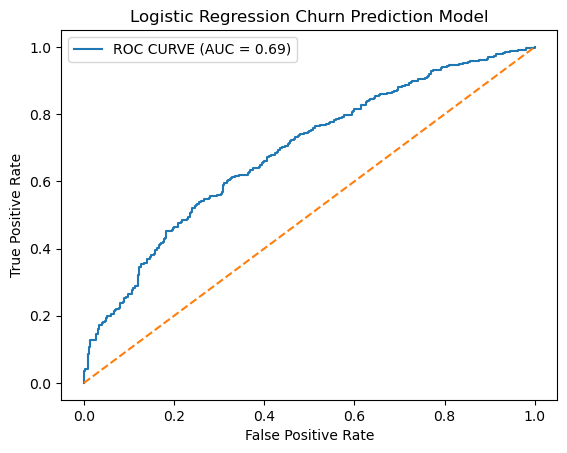

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.3f}")

plt.figure()
plt.plot(fpr, tpr, label="ROC CURVE (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate") # False positive rate = (False positives) / (False positives + True negatives)
                                  # False positive rate tells you the proportion of non-churned customers incorrectly classified
                                  # False positives = non-churned customers incorrectly classified as churned
                                  # True negatives = non-churned customers correctly classified as non-churned

plt.ylabel("True Positive Rate") # True positive rate = (True positives) / (True positives + False negatives)
                                 # True positive rate tells you the proportion of churned customers correctly classified
                                 # True positives = churned customers correctly classified as churned
                                 # False negatives = churned customers incorrectly classified as not churned 

plt.title("Logistic Regression Churn Prediction Model")
plt.legend()
plt.show() # Create Receiver Operator Characteristic (ROC) Curve

Accuracy: 0.646

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.59      0.49      0.54       350
       Churn       0.68      0.76      0.71       490

    accuracy                           0.65       840
   macro avg       0.63      0.62      0.63       840
weighted avg       0.64      0.65      0.64       840



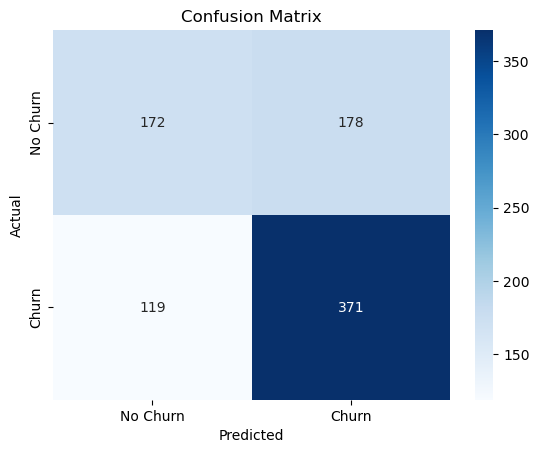

In [11]:
# Model performance at the default 0.5 threshold
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
# Because features were standardized above, these coefficients are on the same
# scale and can be directly compared to rank feature importance.
print(coefficients.sort_values(by = "Coefficient", ascending = False)) # Show feature importance

                  Feature  Coefficient
2        payment_failures     0.502014
1     last_login_days_ago     0.439607
3         support_tickets     0.364010
0  avg_weekly_usage_hours    -0.258693


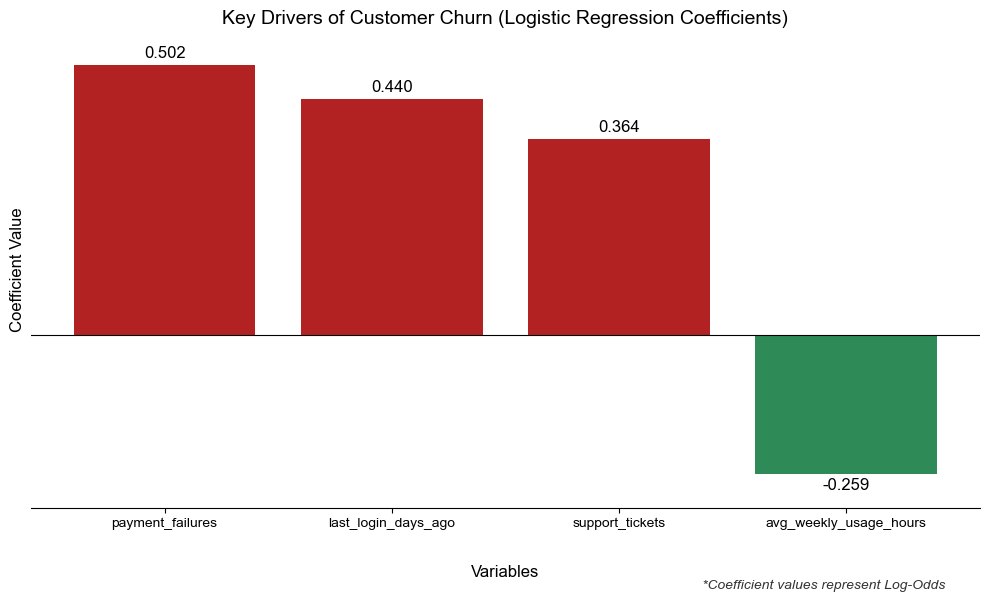

In [13]:
# Set font to Arial

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 1. Sort the features by coefficient value for a cleaner visual flow
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10, 6))

# 2. Use a color conditional: Red for features increasing churn, Green for decreasing
colors = ['firebrick' if x > 0 else 'seagreen' for x in coefficients['Coefficient']]

bars = plt.bar(coefficients['Feature'], coefficients['Coefficient'], color=colors)

# 3. Clean up the labels and layout
plt.axhline(0, color='black', linewidth=0.8)  # Adds a clear baseline
plt.title("Key Drivers of Customer Churn (Logistic Regression Coefficients)", fontsize=14, pad=15)
plt.xlabel("Variables", fontsize=12, labelpad=25)
plt.ylabel("Coefficient Value", fontsize=12)

# 4. Rotate labels
plt.xticks(rotation=45, ha='right')

# 5. Force the x-axis line to the very bottom of the plot instead of at 0
plt.gca().spines['bottom'].set_position(('outward', 10))

# 6. Set data labels for bars
plt.bar_label(bars, padding=3, fmt='%.3f', fontsize=12)

# 7. Clean up the borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([])

plt.tight_layout() # Adjusts layout so labels don't get cut off

# Add a note about Log-Odds at the bottom right
plt.figtext(0.95, 0.01, "*Coefficient values represent Log-Odds", 
            horizontalalignment='right', fontsize=10, style='italic', color='black', alpha=0.8)

# Create a dictionary to map old names to new names
rename_map = {
    'payment_failures': 'Payment Failures',
    'support_tickets': 'Support Tickets',
    'last_login_days_ago': 'Recency',
    'avg_weekly_usage_hours': 'Usage'
}

# Rename
coefficients['Feature'] = coefficients['Feature'].replace(rename_map)

plt.savefig("logistic_regression_coefficients_clean.png", bbox_inches="tight", dpi=300)
plt.show()